In [1]:
import os
from mp_api.client import MPRester

api_key = os.environ["MP_API_KEY"]

with MPRester(api_key) as mpr:
    # Pull ytterbium disilicate, a real EBC material
    docs = mpr.materials.summary.search(
        formula="Yb2Si2O7",
        fields=["material_id", "formula_pretty", "symmetry", "energy_above_hull"]
    )

for d in docs:
    print(d.material_id, d.formula_pretty, d.symmetry.symbol, d.energy_above_hull)

/Users/justin/miniforge3/envs/ebc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving SummaryDoc documents: 100%|█| 1/1 [00:00<00:00, 

mp-4300 Yb2Si2O7 C2/m 0.0


In [2]:
with MPRester(api_key) as mpr:
    structure = mpr.get_structure_by_material_id("mp-4300")

print(structure)
structure.to(filename="Yb2Si2O7.cif")
print("\nSaved to Yb2Si2O7.cif")

Retrieving MaterialsDoc documents: 100%|█| 1/1 [00:00<00:00

Full Formula (Yb2 Si2 O7)
Reduced Formula: Yb2Si2O7
abc   :   5.546756   5.546756   4.715857
angles:  82.663666  82.663666 105.156111
pbc   :       True       True       True
Sites (11)
  #  SP           a         b         c    magmom
---  ----  --------  --------  --------  --------
  0  Yb    0.307651  0.692349  0               -0
  1  Yb    0.692349  0.307651  0               -0
  2  Si    0.779589  0.779589  0.411022         0
  3  Si    0.220411  0.220411  0.588978         0
  4  O     0.915708  0.611782  0.218708        -0
  5  O     0.388218  0.084292  0.781292        -0
  6  O     0.611782  0.915708  0.218708        -0
  7  O     0.084292  0.388218  0.781292        -0
  8  O     0         0         0.5             -0
  9  O     0.385312  0.385312  0.283739         0
 10  O     0.614688  0.614688  0.716261         0

Saved to Yb2Si2O7.cif


In [3]:
import pandas as pd
from mp_api.client import MPRester

rare_earths = ["La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd",
               "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu", "Y", "Sc"]

results = []
with MPRester(api_key) as mpr:
    for re in rare_earths:
        docs = mpr.materials.summary.search(
            chemsys=f"{re}-Si-O",
            fields=["material_id", "formula_pretty", "symmetry",
                    "energy_above_hull", "formation_energy_per_atom",
                    "density", "volume", "nsites", "band_gap"]
        )
        for d in docs:
            results.append({
                "material_id": d.material_id,
                "formula": d.formula_pretty,
                "rare_earth": re,
                "space_group": d.symmetry.symbol,
                "crystal_system": d.symmetry.crystal_system,
                "e_above_hull": d.energy_above_hull,
                "formation_energy": d.formation_energy_per_atom,
                "density": d.density,
                "volume": d.volume,
                "nsites": d.nsites,
                "band_gap": d.band_gap,
            })

df = pd.DataFrame(results)
print(f"Found {len(df)} rare-earth silicate entries")
df.head(20)

Retrieving SummaryDoc documents: 100%|█| 15/15 [00:00<00:00
Retrieving SummaryDoc documents: 100%|█| 5/5 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 4/4 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 6/6 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 6/6 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 7/7 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 6/6 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 4/4 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 5/5 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 4/4 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 4/4 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 3/3 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 3/3 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 6/6 [00:00<00:00, 
Retrieving SummaryDoc documents: 100%|█| 13/13 [00:00<00:00
Retrieving SummaryDoc documents: 100%|█| 4/4 [00:00<00:00, 

Found 95 rare-earth silicate entries


,material_id,formula,rare_earth,space_group,crystal_system,e_above_hull,formation_energy,density,volume,nsites,band_gap
0,mp-531302,La10(Si2O9)3,La,Pc,Monoclinic,0.024278,-3.727459,5.366376,1231.269647,86,3.3817
1,mp-555465,La10Si8O3,La,P6/mmm,Hexagonal,0.030996,-1.436848,5.656259,487.845256,21,0.0000
2,mp-756325,La2(SiO3)3,La,P-1,Triclinic,0.100489,-3.487509,5.124362,327.976746,28,4.4199
3,mp-756888,La2(SiO3)3,La,P6_3/m,Hexagonal,0.030152,-3.557846,4.041668,415.836149,28,4.3297
4,mp-852194,La2(SiO3)3,La,P-1,Triclinic,3.097200,-0.490798,5.124362,327.976752,28,0.0000
5,mp-1185023,La2Si2O5,La,P4/mmm,Tetragonal,0.657803,-2.700842,6.009356,114.392997,9,0.0000
6,mp-18639,La2Si2O7,La,P-1,Triclinic,0.009667,-3.664286,4.928313,601.068548,44,4.5629
7,mp-555800,La2Si2O7,La,P2_1/c,Monoclinic,0.024688,-3.649264,4.971051,1787.702761,132,4.3808
8,mp-5732,La2Si2O7,La,P2_1/c,Monoclinic,0.000000,-3.673952,4.697627,630.585127,44,4.7992
9,mp-5974,La2Si2O7,La,P4_1,Tetragonal,0.008582,-3.665371,5.105726,1160.365289,88,4.6738


In [4]:
df.to_csv("rare_earth_silicates.csv", index=False)
print(f"Saved {len(df)} entries to rare_earth_silicates.csv")

Saved 95 entries to rare_earth_silicates.csv


In [5]:
# How many compounds per rare earth?
df.groupby("rare_earth").size().sort_values(ascending=False)

rare_earth
La    15
Y     13
Eu     7
Gd     6
Lu     6
Nd     6
Sm     6
Ce     5
Dy     5
Er     4
Ho     4
Pr     4
Sc     4
Tb     4
Tm     3
Yb     3
dtype: int64

In [6]:
# Which compositions show up?
df["formula"].value_counts().head(20)

formula
Y2Si2O7       7
La2Si2O7      5
Sm2Si2O7      3
Ce2Si2O7      3
Nd2Si2O7      3
Y2SiO5        3
Gd2Si2O7      3
Lu2Si2O7      3
Dy2SiO5       3
La2SiO5       3
La2(SiO3)3    3
Er2SiO5       2
Er2Si2O7      2
Eu2SiO5       2
Ho2Si2O7      2
Eu2SiO4       2
Eu2Si2O7      2
Tm2Si2O7      2
Dy2Si2O7      2
Lu2SiO5       2
Name: count, dtype: int64

In [7]:
# How many are thermodynamically stable (on the convex hull)?
stable = df[df["e_above_hull"] == 0]
print(f"{len(stable)} stable compounds out of {len(df)}")
stable[["formula", "space_group", "density"]].head(20)

25 stable compounds out of 95


,formula,space_group,density
8,La2Si2O7,P2_1/c,4.697627
11,La2SiO5,P2_1/c,5.483199
17,Ce2Si2O7,P2_1/c,4.645187
21,Pr2Si2O7,P2_1/c,4.840443
24,Nd2Si2O7,P4_1,5.448964
27,Nd2SiO5,P2_1/c,5.949308
30,Sm2Si2O7,P-1,5.232008
33,Sm2SiO5,P2_1/c,6.401027
39,Eu2SiO4,P2_1/c,6.787915
43,Gd2Si2O7,Pnma,5.503865


In [8]:
# What space groups are most common?
df["space_group"].value_counts().head(10)

space_group
P2_1/c      25
P-1         11
Pm-3m        9
C2/c         8
Pnma         8
C2/m         6
P6_3/m       5
P4_1         5
I4_1/amd     3
P2_1/m       2
Name: count, dtype: int64

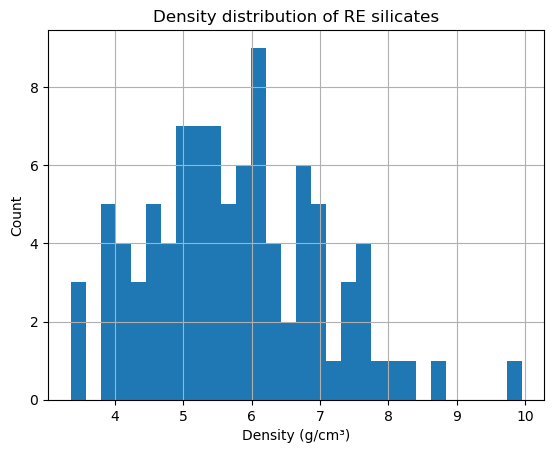

In [9]:
# Density distribution — useful because EBC density affects CTE matching with SiC/SiC
import matplotlib.pyplot as plt
df["density"].hist(bins=30)
plt.xlabel("Density (g/cm³)")
plt.ylabel("Count")
plt.title("Density distribution of RE silicates")
plt.show()

In [10]:
# Filter to just the EBC-relevant phases
ebc_phases = df[df["formula"].str.contains("Si2O7|SiO5", regex=True)]
print(f"EBC-relevant phases: {len(ebc_phases)} entries")

# Among stable EBC phases, how does density vary with rare earth?
stable_ebc = ebc_phases[ebc_phases["e_above_hull"] == 0]
print(stable_ebc.groupby("rare_earth")["density"].mean().sort_values())

EBC-relevant phases: 65 entries
rare_earth
Sc    3.373334
Y     4.343168
Ce    4.645187
Pr    4.840443
La    5.090413
Nd    5.699136
Sm    5.816517
Tm    6.085429
Gd    6.138784
Yb    6.236823
Er    6.527099
Tb    6.562622
Ho    6.694122
Dy    6.765194
Lu    6.973995
Name: density, dtype: float64


In [11]:
from pymatgen.analysis.reaction_calculator import ComputedReaction
from pymatgen.entries.computed_entries import ComputedEntry
from mp_api.client import MPRester
import os

api_key = os.environ["MP_API_KEY"]

# CMAS-relevant chemical system: the EBC + Ca-Mg-Al-Si-O
# A simplified "model CMAS" is anorthite-like: CaAl2Si2O8
# We'll pull all entries in the relevant chemistry from MP

# Start with one example: Yb2Si2O7 reacting with CaO (simplest CMAS proxy)
with MPRester(api_key) as mpr:
    # Get the full Yb-Si-O-Ca-Al-Mg chemical system entries
    entries = mpr.get_entries_in_chemsys(["Yb", "Si", "O", "Ca", "Al", "Mg"])

print(f"Pulled {len(entries)} entries from the Yb-Si-O-Ca-Al-Mg chemical system")

/var/folders/vc/ftrvsw9s5cq1t71b55s23vl80000gn/T/ipykernel_68356/181279370.py:15: MPRestWarning: The default thermo type when retrieving entries has been changed from the mixed/corrected PBE GGA and GGA+U hull (`thermo_type = GGA_GGA+U`) to the joint PBE GGA / GGA+U / r2SCAN hull (`thermo_type = GGA_GGA+U_R2SCAN`). To use the older behavior, call `get_entries_in_chemsys` with `additional_criteria = {"thermo_types": ["GGA_GGA+U"]}`
  entries = mpr.get_entries_in_chemsys(["Yb", "Si", "O", "Ca", "Al", "Mg"])
Retrieving ThermoDoc documents: 100%|█| 1843/1843 [00:01<00
/Users/justin/miniforge3/envs/ebc/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Pulled 1861 entries from the Yb-Si-O-Ca-Al-Mg chemical system


In [15]:
from mp_api.client import MPRester
from pymatgen.analysis.phase_diagram import PhaseDiagram
from pymatgen.core import Composition
import os

api_key = os.environ["MP_API_KEY"]

with MPRester(api_key) as mpr:
    # Force the legacy thermo type — more stable for phase diagram work
    entries = mpr.get_entries_in_chemsys(
        ["Yb", "Si", "O", "Ca"],
        additional_criteria={"thermo_types": ["GGA_GGA+U"]}
    )

print(f"Total entries pulled: {len(entries)}")

# Show all Yb-Si-O ternaries (no Ca) in the result
ybsio_entries = [e for e in entries 
                 if set(str(el) for el in e.composition.elements) <= {"Yb", "Si", "O"}
                 and "Yb" in [str(el) for el in e.composition.elements]]

print(f"\nYb-Si-O containing entries: {len(ybsio_entries)}")
for e in ybsio_entries[:20]:
    print(f"  {e.entry_id}  {e.composition.reduced_formula}")

Retrieving ThermoDoc documents: 100%|█| 521/521 [00:00<00:0


Total entries pulled: 521

Yb-Si-O containing entries: 0
